In [24]:
from numpy.linalg import norm
from numpy.random import randn
import numpy as np
import math
from math import atan2
from filterpy.kalman import UnscentedKalmanFilter as UKF
from filterpy.common import Q_discrete_white_noise
from filterpy.kalman import unscented_transform, MerweScaledSigmaPoints
import matplotlib.pyplot as plt
import pandas as pd
import os
import random

In [25]:
def load_data(PRMA, PRMP):
    df_list_MA_features = []
    df_list_MA_labels = []
    df_list_MP_features = []
    df_list_MP_labels = []
    df_day_time = []

    days = ["20181024", "20181029", "20181030","20181101"]
    times = ["0800_0830", "0830_0900", "0900_0930", "0930_1000", "1000_1030", "1030_1100"]

    for day in days:
        for timetime in times:
            # some data is not good to use
            if not os.path.exists(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MA_features.csv"):
                continue
            if day == "20181101" and timetime == "0800_0830":
                continue
            if day == "20181029" and timetime == "1000_1030":
                continue
            if day == "20181030" and timetime == "0930_1000":
                continue
            if day == "20181030" and timetime == "1000_1030":
                continue
            # read data
            df_MA_features = pd.read_csv(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MA_features.csv")
            df_list_MA_features.append(df_MA_features)
            df_MP_features = pd.read_csv(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MP_features.csv")
            df_list_MP_features.append(df_MP_features)
            df_MA_labels = pd.read_csv(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MA_labels.csv")
            df_list_MA_labels.append(df_MA_labels)
            df_MP_labels = pd.read_csv(f"../datasets_pneuma_corrider/MA_{PRMA}_MP_{PRMP}_ma/{day}_{timetime}_MP_labels.csv")
            df_list_MP_labels.append(df_MP_labels)
            # save the length of data
            df_day_time.append(len(df_MA_features))

    df_X_MA = pd.concat(df_list_MA_features)
    df_Y_MA = pd.concat(df_list_MA_labels)
    df_X_MP = pd.concat(df_list_MP_features)
    df_Y_MP = pd.concat(df_list_MP_labels)
    # delete the first column
    df_X_MA = df_X_MA.drop(df_X_MA.columns[0], axis=1)
    df_Y_MA = df_Y_MA.drop(df_Y_MA.columns[0], axis=1)
    df_X_MP = df_X_MP.drop(df_X_MP.columns[0], axis=1)
    df_Y_MP = df_Y_MP.drop(df_Y_MP.columns[0], axis=1)

    # print(df_X_MA.head(), df_Y_MA.head(), df_X_MP.head(), df_Y_MP.head())
    # print(df_X_MA.shape, df_Y_MA.shape, df_X_MP.shape, df_Y_MP.shape)

    np_X_MA = df_X_MA.values.reshape(-1, 17, 1) # counts
    np_X_MP = df_X_MP.values.reshape(-1, 17, 3) # total travel time and total travel distance
    # np_X_MP = np_X_MP[:, :, :2] # delete the speed

    np_Y_MP_qk = df_Y_MP.values.reshape(-1, 17, 3)
    np_Y_MP = np_Y_MP_qk[:, :, 1].reshape(-1, 17, 1)  # density veh/km
    # np_Y_MA = df_Y_MA.values.reshape(-1, 17, 1) * 360 / 60  # volume veh/min
    np_Y_MA = np_Y_MP_qk[:, :, 0].reshape(-1, 17, 1)  # density veh/min
    
    # merge the y of MA and MP
    np_Y = np.concatenate((np_Y_MA, np_Y_MP), axis=2)

    # split the data into train validation and test 0.6 0.2 0.2
    # train
    X_MA_train = np_X_MA[:sum(df_day_time[:-4])]
    X_MP_train = np_X_MP[:sum(df_day_time[:-4])]
    Y_train = np_Y[:sum(df_day_time[:-4])]
    # validation
    X_MA_val = np_X_MA[sum(df_day_time[:-4]):sum(df_day_time[:-3])]
    X_MP_val = np_X_MP[sum(df_day_time[:-4]):sum(df_day_time[:-3])]
    Y_val = np_Y[sum(df_day_time[:-4]):sum(df_day_time[:-3])]
    # test
    X_MA_test = np_X_MA[sum(df_day_time[:-3]):]
    X_MP_test = np_X_MP[sum(df_day_time[:-3]):]
    Y_test = np_Y[sum(df_day_time[:-3]):]

    return X_MA_train, X_MP_train, Y_train, X_MA_val, X_MP_val, Y_val, X_MA_test, X_MP_test, Y_test, df_day_time

_, _, _, _, _, _, X_MA_test, X_MP_test, Y_test, df_day_time = load_data(1, 0.8)
X_MP_test_1 = X_MP_test[:sum(df_day_time[-3:-2]),[2,3,8],-1:] # km/min
X_MP_test_2 = X_MP_test[sum(df_day_time[-3:-2]):sum(df_day_time[-3:-1]),[2,3,8],-1:] # km/min
X_MP_test_3 = X_MP_test[sum(df_day_time[-3:-1]):sum(df_day_time[-3:  ]),[2,3,8],-1:] # km/min
X_MA_test_1 = X_MA_test[:sum(df_day_time[-3:-2]),[2,3,8],:] * 6 # veh/min
X_MA_test_2 = X_MA_test[sum(df_day_time[-3:-2]):sum(df_day_time[-3:-1]),[2,3,8],:] * 6 # veh/min
X_MA_test_3 = X_MA_test[sum(df_day_time[-3:-1]):sum(df_day_time[-3:  ]),[2,3,8],:] * 6 # veh/min
# print(X_MP_test_1.shape, X_MP_test_2.shape, X_MP_test_3.shape, X_MA_test_1.shape, X_MA_test_2.shape, X_MA_test_3.shape)
Y_test_1 = Y_test[:sum(df_day_time[-3:-2]),[2,3,8],:] # veh/km
obs = np.concatenate((X_MA_test_1, X_MP_test_1), axis=2)
obs[[20],[1],[1]]
demand = X_MP_test[:sum(df_day_time[-3:-2]),[2],2] # km/min
demand.shape
demand[10][0]
demand
Y_test[:,0,1]
# 使用Y_test[:,0,1]生成一个distribution
# 随机从Y_test[:,0,1]里面抽取一个值
random.choice(Y_test[:,0,1])





170.75102444997177

In [77]:
# CTM model update non-linear function
def f_ctm(x, dt):
    q_3, q_4, q_r = x[0]/60, x[2]/60, x[4]/60     # veh/s
    k_3, k_4, k_r = x[1]/1000, x[3]/1000, x[5]/1000     # veh/m

    vf_3, vf_4, vf_r = 10.119, 8.982, 6.159
    w_3, w_4, w_r = 5.046, 5.386, 4.038
    kj_3, kj_4, kj_r = 0.495, 0.495, 0.205

    S_3 = np.min([ vf_3*k_3 , w_3*kj_3*vf_3/(w_3+vf_3) ]) # veh/s
    S_4 = np.min([ vf_4*k_4 , w_4*kj_4*vf_4/(w_4+vf_4) ]) # veh/s
    S_r = np.min([ vf_r*k_r , w_r*kj_r*vf_r/(w_r+vf_r) ]) # veh/s
    R_4 = np.min([ w_4*kj_4*vf_4/(w_4+vf_4) , w_4*(kj_4-k_4) ]) # veh/s
    R_r = np.min([ w_r*kj_r*vf_r/(w_r+vf_r) , w_r*(kj_r-k_r) ]) # veh/s
    # assert
    # try
    # except

    S_3 = np.max([ S_3 , 0 ])
    S_4 = np.max([ S_4 , 0 ])
    S_r = np.max([ S_r , 0 ])
    R_4 = np.max([ R_4 , 0 ])
    R_r = np.max([ R_r , 0 ])

    tr = 0.9
    Q_34 = np.min([ S_3*tr , R_4 ])
    Q_3r = np.min([ S_3*(1-tr) , R_r ])

    
    q_3_upd, k_3_upd = fd_calculate(k_3, vf_3, w_3, kj_3) # 需要处理一下 140.22
    q_4_upd, k_4_upd = fd_calculate(k_4 + (Q_34 - S_4) * dt/98.22, vf_4, w_4, kj_4)
    q_r_upd, k_r_upd = fd_calculate(k_r + (Q_3r - S_r) * dt/173.78, vf_r, w_r, kj_r)
    print(q_3_upd, k_3_upd, q_4_upd, k_4_upd, q_r_upd, k_r_upd)

    return np.array([q_3_upd, k_3_upd, q_4_upd, k_4_upd, q_r_upd, k_r_upd])

def fd_calculate(k_update, vf, w, kj):
    if k_update < 0:
        q_update = 0
        k_update = 0
    elif k_update > kj:
        q_update = 0
        k_update = kj
    elif 0 <= k_update <= w*kj/(w+vf):
        q_update = vf * k_update
        k_update = k_update
    else:
        q_update = w * (kj - k_update)
        k_update = k_update
    return q_update*60, k_update*1000

def h_ma_mp(x):
    ''' q1, k1, q2, k2, q3, k3'''
    if x[1] == 0:
        v1_e3 = 0
    else:
        v1_e3 = x[0] / x[1]
    if x[3] == 0:
        v2_e4 = 0
    else:
        v2_e4 = x[2] / x[3]
    if x[5] == 0:
        v3_ramp = 0
    else:
        v3_ramp = x[4] / x[5]
    q_e4 = x[2]
    # print(v1_e3, v2_e4, v3_ramp, q_e4)
    return [v1_e3, v2_e4, v3_ramp, q_e4]

In [46]:
fd_calculate(0.127, 10.119, 5.046, 0.495)

(77.10678, 127.0)

In [54]:
def plot_radar(xs, t, plot_x=True, plot_vel=True, plot_alt=True):
    xs = np.asarray(xs)
    if plot_x:
        plt.figure()
        plt.plot(t, xs[:, 0]/1000.)
        plt.xlabel('time(sec)')
        plt.ylabel('position(km)')
        plt.tight_layout()
    if plot_vel:
        plt.figure()
        plt.plot(t, xs[:, 1])
        plt.xlabel('time(sec)')
        plt.ylabel('velocity')
        plt.tight_layout()
    if plot_alt:
        plt.figure()
        plt.plot(t, xs[:,2])
        plt.xlabel('time(sec)')
        plt.ylabel('altitude')
        plt.tight_layout()
    plt.show()

In [78]:
dt = 10. # 10 sec
points = MerweScaledSigmaPoints(n=6, alpha=.1, beta=2., kappa=0.) # 6 states
kf = UKF(6, 1, dt, fx=f_ctm, hx=h_ma_mp, points=points) # 6 states, 4 measurements
# 用ctm 看残差

# define the noise
kf.Q = np.diag([3**2, 10**2, 3**2, 10**2, 3**2, 10**2])


kf.R = np.diag([1**2, 1**2, 1**2, 3**2])

kf.x = np.array([Y_test_1[0,0,0], Y_test_1[0,0,1], 
                 Y_test_1[0,1,0], Y_test_1[0,1,1], 
                 Y_test_1[0,2,0], Y_test_1[0,2,1]]) # initial state q1, k1, q2, k2, q3, k3
kf.P = np.diag([10**2, 50**2, 10**2, 50**2, 10**2, 50**2]) # initial uncertainty

np.random.seed(2023)

time = np.arange(0, df_day_time[-3]-1)
xs = []
for t in time:
    kf.predict()
    kf.update([obs[[t+1],[0],[1]][0], obs[[t+1],[1],[1]][0], 
               obs[[t+1],[2],[1]][0], obs[[t+1],[1],[0]][0]]) # v1, v2, v3, q1
    # kf.update([obs[[t+1],[0],[0]][0]]) # v1, v2, v3, q1
    xs.append(kf.x)
# plot_radar(xs, time)


74.15150002443293 122.1324571341584 64.74659001727987 120.14137537534305 14.337952215558392 38.79945936991501
74.15150002443293 122.1324571341584 64.74659001727987 120.14137537534305 14.337952215558392 38.79945936991501
81.5874160365998 134.37990584807426 70.86657147310909 131.497386389648 14.601491211524186 39.51261355069596
74.15150002443293 122.1324571341584 64.74659001727987 120.14137537534305 14.337952215558392 38.79945936991501
74.15150002443293 122.1324571341584 65.31107096323375 121.1888053203328 14.337952215558392 38.79945936991501
74.15150002443293 122.1324571341584 64.74659001727987 120.14137537534305 14.337952215558392 38.79945936991501
74.15150002443293 122.1324571341584 64.74659001727987 120.14137537534305 17.25982591428381 46.70624537068736
74.15150002443293 122.1324571341584 64.74659001727987 120.14137537534305 14.337952215558392 38.79945936991501
66.71558401226605 109.88500842024254 58.62660856145065 108.78536436103809 14.074413219592596 38.08630518913405
74.1515000244

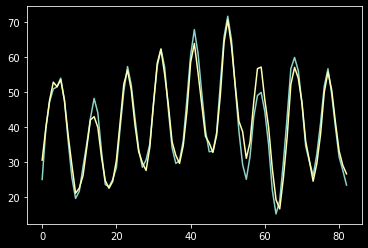

43.96119309639651


(83, 3, 2)

In [79]:
from matplotlib import pyplot as plt
plt.plot(Y_test_1[1:,1,0])
Y_est_1 = np.array(xs).reshape(-1,3,2)
plt.plot(Y_est_1[:,1,0])
plt.show()

# calculate the rmse
from sklearn.metrics import mean_squared_error
from math import sqrt
rms = sqrt(mean_squared_error(Y_test_1[1:,0,1], Y_est_1[:,0,1]))
print(rms)
Y_est_1.shape